In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import os

print(os.listdir('/kaggle/input'))

In [ ]:
import os

print("Contents of /kaggle/input:")
print(os.listdir('/kaggle/input'))

In [ ]:
import os

for item in os.listdir('/kaggle/input'):
    print(item)

In [ ]:
import os

print(os.listdir('/kaggle/input/datasets'))

In [ ]:
import os

for root, dirs, files in os.walk('/kaggle/input/datasets'):
    print(root)
    print("Folders:", dirs)
    print("Files:", len(files))
    print("-"*50)

In [ ]:
import os

IMG_PATH = "/kaggle/input/datasets/prksh830/pancreatic-dataset/Processed/images"
LBL_PATH = "/kaggle/input/datasets/prksh830/pancreatic-dataset/Processed/labels"

print("Image files:")
print(os.listdir(IMG_PATH)[:10])

print("\nLabel files:")
print(os.listdir(LBL_PATH)[:10])

In [ ]:
!pip install nibabel -q

In [ ]:
import nibabel as nib
import numpy as np
import os

IMG_PATH = "/kaggle/input/datasets/prksh830/pancreatic-dataset/Processed/images"
LBL_PATH = "/kaggle/input/datasets/prksh830/pancreatic-dataset/Processed/labels"

sample = sorted(os.listdir(IMG_PATH))[0]

print("Sample:", sample)

image = nib.load(os.path.join(IMG_PATH, sample)).get_fdata()
label = nib.load(os.path.join(LBL_PATH, sample)).get_fdata()

print("Image Shape :", image.shape)
print("Label Shape :", label.shape)
print("Image dtype :", image.dtype)
print("Unique Labels :", np.unique(label))

In [ ]:
import matplotlib.pyplot as plt

mid = image.shape[2] // 2

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image[:,:,mid], cmap='gray')
plt.title("CT")

plt.subplot(1,2,2)
plt.imshow(label[:,:,mid])
plt.title("Mask")

plt.show()

In [ ]:
import os

split_path = "/kaggle/input/datasets/prksh830/pancreatic-dataset/Processed/splits"

for f in os.listdir(split_path):
    print(f)

In [ ]:
import json
import os

split_path = "/kaggle/input/datasets/prksh830/pancreatic-dataset/Processed/splits"

for file in ["train.json", "val.json", "test.json"]:

    print("\n", "="*50)
    print(file)

    with open(os.path.join(split_path, file), "r") as f:
        data = json.load(f)

    print(type(data))

    if isinstance(data, list):
        print("Length:", len(data))
        print("First Entry:", data[0])

    elif isinstance(data, dict):
        print("Keys:", data.keys())

In [ ]:
import os
import json
import nibabel as nib
import numpy as np
import pandas as pd
from tqdm import tqdm

BASE_PATH = "/kaggle/input/datasets/prksh830/pancreatic-dataset/Processed"

IMAGE_PATH = os.path.join(BASE_PATH, "images")
LABEL_PATH = os.path.join(BASE_PATH, "labels")
SPLIT_PATH = os.path.join(BASE_PATH, "splits")

# Load train split
with open(os.path.join(SPLIT_PATH, "train.json"), "r") as f:
    train_files = json.load(f)

records = []

for fname in tqdm(train_files):

    mask = nib.load(os.path.join(LABEL_PATH, fname)).get_fdata()

    total_slices = mask.shape[2]

    for s in range(total_slices):

        slice_mask = mask[:, :, s]

        tumor_pixels = np.sum(slice_mask == 2)

        label = 1 if tumor_pixels > 0 else 0

        records.append([
            fname,
            s,
            label,
            tumor_pixels
        ])

df = pd.DataFrame(
    records,
    columns=[
        "patient",
        "slice_id",
        "label",
        "tumor_pixels"
    ]
)

df.to_csv("slice_inventory.csv", index=False)

print(df.head())

print("\nTotal slices :", len(df))
print("Tumor slices :", (df["label"] == 1).sum())
print("Non-tumor slices :", (df["label"] == 0).sum())

In [ ]:
import os
import json
import nibabel as nib
import numpy as np
from tqdm import tqdm

BASE_PATH = "/kaggle/input/datasets/prksh830/pancreatic-dataset/Processed"

LABEL_PATH = os.path.join(BASE_PATH, "labels")

with open(os.path.join(BASE_PATH, "splits/train.json")) as f:
    train_files = json.load(f)

tumor_slices = 0
pancreas_only_slices = 0
background_slices = 0

for fname in tqdm(train_files):

    mask = nib.load(
        os.path.join(LABEL_PATH, fname)
    ).get_fdata()

    for s in range(mask.shape[2]):

        sl = mask[:, :, s]

        if np.any(sl == 2):
            tumor_slices += 1

        elif np.any(sl == 1):
            pancreas_only_slices += 1

        else:
            background_slices += 1

print("Tumor Slices:", tumor_slices)
print("Pancreas Only Slices:", pancreas_only_slices)
print("Background Slices:", background_slices)

In [ ]:
import os
import json
import numpy as np
import nibabel as nib
import cv2
from tqdm import tqdm

In [ ]:
BASE_PATH = "/kaggle/input/datasets/prksh830/pancreatic-dataset/Processed"

IMAGE_PATH = os.path.join(BASE_PATH, "images")
LABEL_PATH = os.path.join(BASE_PATH, "labels")
SPLIT_PATH = os.path.join(BASE_PATH, "splits")

OUTPUT_PATH = "/kaggle/working/ERSF_DATASET"

os.makedirs(OUTPUT_PATH, exist_ok=True)

In [ ]:
for split in ["train", "val", "test"]:

    os.makedirs(
        os.path.join(OUTPUT_PATH, split, "tumor"),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(OUTPUT_PATH, split, "pancreas"),
        exist_ok=True
    )

print("Folders Created")

In [ ]:
def process_split(split_name):

    with open(
        os.path.join(SPLIT_PATH, f"{split_name}.json"),
        "r"
    ) as f:

        file_list = json.load(f)

    tumor_count = 0
    pancreas_count = 0

    for fname in tqdm(file_list):

        image = nib.load(
            os.path.join(IMAGE_PATH, fname)
        ).get_fdata()

        mask = nib.load(
            os.path.join(LABEL_PATH, fname)
        ).get_fdata()

        patient_id = fname.replace(".nii", "")

        total_slices = image.shape[2]

        for s in range(total_slices):

            img_slice = image[:, :, s]
            mask_slice = mask[:, :, s]

            # Tumor Slice
            if np.any(mask_slice == 2):

                label_folder = "tumor"
                tumor_count += 1

            # Pancreas Only Slice
            elif np.any(mask_slice == 1):

                label_folder = "pancreas"
                pancreas_count += 1

            # Background Slice
            else:
                continue

            # Intensity normalization
            img_slice = img_slice.astype(np.float32)

            img_slice = (
                img_slice - img_slice.min()
            ) / (
                img_slice.max() - img_slice.min() + 1e-8
            )

            img_slice = (img_slice * 255).astype(np.uint8)

            # Resize
            img_slice = cv2.resize(
                img_slice,
                (224,224),
                interpolation=cv2.INTER_LINEAR
            )

            save_name = (
                f"{patient_id}_slice_{s}.png"
            )

            save_path = os.path.join(
                OUTPUT_PATH,
                split_name,
                label_folder,
                save_name
            )

            cv2.imwrite(
                save_path,
                img_slice
            )

    print(
        f"{split_name}: "
        f"Tumor={tumor_count}, "
        f"Pancreas={pancreas_count}"
    )

In [ ]:
process_split("train")
process_split("val")
process_split("test")

In [ ]:
for split in ["train","val","test"]:

    tumor = len(
        os.listdir(
            os.path.join(
                OUTPUT_PATH,
                split,
                "tumor"
            )
        )
    )

    pancreas = len(
        os.listdir(
            os.path.join(
                OUTPUT_PATH,
                split,
                "pancreas"
            )
        )
    )

    print(
        split,
        "Tumor =", tumor,
        "Pancreas =", pancreas
    )

In [ ]:
import matplotlib.pyplot as plt
import random

tumor_folder = os.path.join(
    OUTPUT_PATH,
    "train",
    "tumor"
)

sample = random.choice(
    os.listdir(tumor_folder)
)

img = cv2.imread(
    os.path.join(tumor_folder,sample),
    cv2.IMREAD_GRAYSCALE
)

plt.figure(figsize=(6,6))
plt.imshow(img,cmap="gray")
plt.title(sample)
plt.axis("off")
plt.show()

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15,6))

tumor_folder = "/kaggle/working/ERSF_DATASET/train/tumor"
pancreas_folder = "/kaggle/working/ERSF_DATASET/train/pancreas"

for i in range(5):

    img_path = os.path.join(
        tumor_folder,
        random.choice(os.listdir(tumor_folder))
    )

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    axes[0,i].imshow(img,cmap='gray')
    axes[0,i].set_title("Tumor")
    axes[0,i].axis('off')

for i in range(5):

    img_path = os.path.join(
        pancreas_folder,
        random.choice(os.listdir(pancreas_folder))
    )

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    axes[1,i].imshow(img,cmap='gray')
    axes[1,i].set_title("Pancreas")
    axes[1,i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

In [ ]:
import os

train_tumor = "/kaggle/working/ERSF_DATASET/train/tumor"

sample = os.listdir(train_tumor)[0]

print(sample)

In [ ]:
import os

print(os.path.exists("/kaggle/working/ERSF_DATASET"))

In [ ]:
import os
print(os.listdir("/kaggle/working"))

In [ ]:
import os

print(os.listdir("/kaggle/working/ERSF_DATASET"))

In [ ]:
for split in ["train","val","test"]:
    print(split)
    print(os.listdir(f"/kaggle/working/ERSF_DATASET/{split}"))

In [ ]:
import os
import cv2

tumor_folder = "/kaggle/working/ERSF_DATASET/train/tumor"

sample = os.listdir(tumor_folder)[0]

img = cv2.imread(
    os.path.join(tumor_folder, sample),
    cv2.IMREAD_GRAYSCALE
)

print("Sample:", sample)
print("Shape:", img.shape)
print("Type:", img.dtype)

In [ ]:
!pip install -q timm

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.datasets import ImageFolder

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from collections import Counter

In [ ]:
DATASET_ROOT = "/kaggle/working/ERSF_DATASET"

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR   = os.path.join(DATASET_ROOT, "val")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

In [ ]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
train_dataset = ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = ImageFolder(
    VAL_DIR,
    transform=val_transform
)

test_dataset = ImageFolder(
    TEST_DIR,
    transform=val_transform
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

print("\nClasses:")
print(train_dataset.class_to_idx)

In [ ]:
train_labels = [x[1] for x in train_dataset.samples]

counter = Counter(train_labels)

print(counter)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_labels)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_labels
)

weights = torch.tensor(
    weights,
    dtype=torch.float32
)

print(weights)

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

In [ ]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(DEVICE)

In [ ]:
model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=2
)

model = model.to(DEVICE)

print("Model Loaded")

In [ ]:
criterion = nn.CrossEntropyLoss(
    weight=weights.to(DEVICE)
)

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

In [ ]:
def evaluate(model, loader):

    model.eval()

    all_preds = []
    all_labels = []

    total_loss = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds
    )

    recall = recall_score(
        all_labels,
        all_preds
    )

    f1 = f1_score(
        all_labels,
        all_preds
    )

    return (
        total_loss / len(loader),
        acc,
        precision,
        recall,
        f1
    )

In [ ]:
EPOCHS = 20

best_f1 = 0

patience = 5
counter = 0

history = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    (
        val_loss,
        val_acc,
        val_prec,
        val_rec,
        val_f1
    ) = evaluate(model, val_loader)

    scheduler.step(val_f1)

    history.append([
        epoch + 1,
        train_loss,
        val_loss,
        val_acc,
        val_prec,
        val_rec,
        val_f1
    ])

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss={train_loss:.4f} | "
        f"Val F1={val_f1:.4f}"
    )

    if val_f1 > best_f1:

        best_f1 = val_f1

        torch.save(
            model.state_dict(),
            "best_swin_tiny.pth"
        )

        counter = 0

    else:

        counter += 1

    if counter >= patience:

        print(
            "Early Stopping Triggered"
        )
        break

In [ ]:
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        probs = torch.softmax(
            outputs,
            dim=1
        )[:,1]

        preds = torch.argmax(
            outputs,
            dim=1
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

        all_probs.extend(
            probs.cpu().numpy()
        )

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUROC    : {auc:.4f}")

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
print(cm)

In [ ]:
!pip install -q pyradiomics

In [ ]:
import SimpleITK as sitk

print("SimpleITK imported successfully")

In [ ]:
import scipy
import sklearn

print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)

In [ ]:
import SimpleITK as sitk
print("OK")

In [ ]:
import scipy
import sklearn

print(scipy.__version__)
print(sklearn.__version__)

In [ ]:
!pip install -q pyradiomics==3.0.1

In [ ]:
import skimage
import scipy
import xgboost

print("skimage :", skimage.__version__)
print("scipy   :", scipy.__version__)
print("xgboost :", xgboost.__version__)

In [ ]:
import os
import json
import cv2
import numpy as np
import pandas as pd
import nibabel as nib

from tqdm import tqdm

from scipy.stats import skew
from scipy.stats import kurtosis

from skimage.measure import regionprops

from skimage.feature import graycomatrix
from skimage.feature import graycoprops

In [ ]:
BASE_PATH = "/kaggle/input/datasets/prksh830/pancreatic-dataset/Processed"

IMAGE_PATH = os.path.join(BASE_PATH, "images")
LABEL_PATH = os.path.join(BASE_PATH, "labels")

In [ ]:
def extract_features(img_slice, mask_slice):

    roi = img_slice[mask_slice > 0]

    if len(roi) < 20:
        return None

    features = {}

    # --------------------------------
    # First Order
    # --------------------------------

    features["mean"] = np.mean(roi)
    features["std"] = np.std(roi)
    features["var"] = np.var(roi)

    features["min"] = np.min(roi)
    features["max"] = np.max(roi)

    features["range"] = (
        np.max(roi) - np.min(roi)
    )

    features["skewness"] = skew(roi)

    features["kurtosis"] = kurtosis(roi)

    hist,_ = np.histogram(
        roi,
        bins=32
    )

    hist = hist / np.sum(hist)

    hist = hist + 1e-10

    features["entropy"] = -np.sum(
       hist * np.log2(hist)
    )

    features["energy"] = np.sum(
        roi.astype(np.float64) ** 2
    )

    # --------------------------------
    # Shape Features
    # --------------------------------

    props = regionprops(
        mask_slice.astype(np.uint8)
    )

    if len(props) > 0:

        p = props[0]

        features["area"] = p.area

        features["perimeter"] = p.perimeter

        features["eccentricity"] = p.eccentricity

        features["solidity"] = p.solidity

        features["extent"] = p.extent

        features["major_axis"] = p.major_axis_length

        features["minor_axis"] = p.minor_axis_length

    else:

        features["area"] = 0
        features["perimeter"] = 0
        features["eccentricity"] = 0
        features["solidity"] = 0
        features["extent"] = 0
        features["major_axis"] = 0
        features["minor_axis"] = 0

    # --------------------------------
    # GLCM Features
    # --------------------------------

    roi_img = img_slice.copy()

    roi_img = cv2.normalize(
        roi_img,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    glcm = graycomatrix(
        roi_img,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    features["contrast"] = graycoprops(
        glcm,
        "contrast"
    )[0,0]

    features["correlation"] = graycoprops(
        glcm,
        "correlation"
    )[0,0]

    features["energy_glcm"] = graycoprops(
        glcm,
        "energy"
    )[0,0]

    features["homogeneity"] = graycoprops(
        glcm,
        "homogeneity"
    )[0,0]

    features["ASM"] = graycoprops(
        glcm,
        "ASM"
    )[0,0]

    features["dissimilarity"] = graycoprops(
        glcm,
        "dissimilarity"
    )[0,0]

    return features

In [ ]:
sample = "pancreas_001.nii"

image = nib.load(
    os.path.join(IMAGE_PATH,sample)
).get_fdata()

mask = nib.load(
    os.path.join(LABEL_PATH,sample)
).get_fdata()

slice_idx = image.shape[2]//2

feat = extract_features(
    image[:,:,slice_idx],
    (mask[:,:,slice_idx]==2)
)

print(feat)

In [ ]:
import os
import numpy as np
import nibabel as nib

LABEL_PATH = "/kaggle/input/datasets/prksh830/pancreatic-dataset/Processed/labels"

tumor_cases = 0
non_tumor_cases = 0

for f in os.listdir(LABEL_PATH):

    mask = nib.load(
        os.path.join(LABEL_PATH, f)
    ).get_fdata()

    if np.any(mask == 2):
        tumor_cases += 1
    else:
        non_tumor_cases += 1

print("Tumor Cases:", tumor_cases)
print("Non-Tumor Cases:", non_tumor_cases)

In [ ]:
import os
import json
import nibabel as nib
import pandas as pd
from tqdm import tqdm

BASE_PATH = "/kaggle/input/datasets/prksh830/pancreatic-dataset/Processed"

IMAGE_PATH = os.path.join(BASE_PATH, "images")
LABEL_PATH = os.path.join(BASE_PATH, "labels")
SPLIT_PATH = os.path.join(BASE_PATH, "splits")

records = []

In [ ]:
with open(os.path.join(SPLIT_PATH,"train.json")) as f:
    train_files = json.load(f)

for fname in tqdm(train_files):

    image = nib.load(
        os.path.join(IMAGE_PATH,fname)
    ).get_fdata()

    mask = nib.load(
        os.path.join(LABEL_PATH,fname)
    ).get_fdata()

    for s in range(image.shape[2]):

        img_slice = image[:,:,s]
        mask_slice = mask[:,:,s]

        # Tumor slice
        if (mask_slice==2).sum() > 0:

            roi_mask = (mask_slice==2)

            label = 1

        # Pancreas-only slice
        elif (mask_slice==1).sum() > 0:

            roi_mask = (mask_slice==1)

            label = 0

        else:
            continue

        feat = extract_features(
            img_slice,
            roi_mask
        )

        if feat is None:
            continue

        feat["patient"] = fname
        feat["slice_id"] = s
        feat["label"] = label
        feat["split"] = "train"

        records.append(feat)

In [ ]:
df = pd.DataFrame(records)

print(df.shape)

df.head()

In [ ]:
print(df.isnull().sum().sort_values(ascending=False).head(20))

In [ ]:
print(df.isna().sum().sum())

In [ ]:
df.to_csv(
    "/kaggle/working/radiomics_train.csv",
    index=False
)

In [ ]:
def extract_split_features(split_name):

    with open(os.path.join(SPLIT_PATH, f"{split_name}.json")) as f:
        file_list = json.load(f)

    records = []

    for fname in tqdm(file_list, desc=f"Processing {split_name}"):

        image = nib.load(
            os.path.join(IMAGE_PATH, fname)
        ).get_fdata()

        mask = nib.load(
            os.path.join(LABEL_PATH, fname)
        ).get_fdata()

        for s in range(image.shape[2]):

            img_slice = image[:, :, s]
            mask_slice = mask[:, :, s]

            # Tumor slice
            if np.sum(mask_slice == 2) > 0:

                roi_mask = (mask_slice == 2)
                label = 1

            # Pancreas-only slice
            elif np.sum(mask_slice == 1) > 0:

                roi_mask = (mask_slice == 1)
                label = 0

            else:
                continue

            feat = extract_features(
                img_slice,
                roi_mask
            )

            if feat is None:
                continue

            feat["patient"] = fname
            feat["slice_id"] = s
            feat["label"] = label
            feat["split"] = split_name

            records.append(feat)

    df_split = pd.DataFrame(records)

    print(f"\n{split_name.upper()} SHAPE:")
    print(df_split.shape)

    return df_split

In [ ]:
val_df = extract_split_features("val")

val_df.head()

In [ ]:
test_df = extract_split_features("test")

test_df.head()

In [ ]:
print("Train NaNs :", train_df.isna().sum().sum())
print("Val NaNs   :", val_df.isna().sum().sum())
print("Test NaNs  :", test_df.isna().sum().sum())

In [ ]:
train_df = df

print("Train Shape:", train_df.shape)
print("Val Shape:", val_df.shape)
print("Test Shape:", test_df.shape)

In [ ]:
print("Train NaNs :", train_df.isna().sum().sum())
print("Val NaNs   :", val_df.isna().sum().sum())
print("Test NaNs  :", test_df.isna().sum().sum())

In [ ]:
print(type(df))
print(df.shape)

In [ ]:
print("Train Shape:", train_df.shape)
print("Val Shape:", val_df.shape)
print("Test Shape:", test_df.shape)

In [ ]:
print("Train NaNs :", train_df.isna().sum().sum())
print("Val NaNs   :", val_df.isna().sum().sum())
print("Test NaNs  :", test_df.isna().sum().sum())

In [ ]:
import numpy as np

numeric_cols = train_df.select_dtypes(include=[np.number]).columns

print("Train Inf:",
      np.isinf(train_df[numeric_cols]).sum().sum())

print("Val Inf:",
      np.isinf(val_df[numeric_cols]).sum().sum())

print("Test Inf:",
      np.isinf(test_df[numeric_cols]).sum().sum())

In [ ]:
df_all = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

print("Combined Shape:", df_all.shape)

In [ ]:
import pandas as pd
import numpy as np

FEATURE_COLUMNS = [
    col for col in train_df.columns
    if col not in [
        "patient",
        "slice_id",
        "label",
        "split"
    ]
]

print("Number of Features:", len(FEATURE_COLUMNS))

In [ ]:
X_train = train_df[FEATURE_COLUMNS]
y_train = train_df["label"]

X_val = val_df[FEATURE_COLUMNS]
y_val = val_df["label"]

X_test = test_df[FEATURE_COLUMNS]
y_test = test_df["label"]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

print(weights)

In [ ]:
from xgboost import XGBClassifier

ratio = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print("scale_pos_weight =", ratio)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [ ]:
xgb_model.fit(
    X_train_scaled,
    y_train
)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

val_pred = xgb_model.predict(
    X_val_scaled
)

val_prob = xgb_model.predict_proba(
    X_val_scaled
)[:,1]

print("Validation")

print(
    "Accuracy:",
    accuracy_score(y_val,val_pred)
)

print(
    "Precision:",
    precision_score(y_val,val_pred)
)

print(
    "Recall:",
    recall_score(y_val,val_pred)
)

print(
    "F1:",
    f1_score(y_val,val_pred)
)

print(
    "AUROC:",
    roc_auc_score(y_val,val_prob)
)

In [ ]:
test_pred = xgb_model.predict(
    X_test_scaled
)

test_prob = xgb_model.predict_proba(
    X_test_scaled
)[:,1]

acc = accuracy_score(
    y_test,
    test_pred
)

prec = precision_score(
    y_test,
    test_pred
)

rec = recall_score(
    y_test,
    test_pred
)

f1 = f1_score(
    y_test,
    test_pred
)

auc = roc_auc_score(
    y_test,
    test_prob
)

print("\nTEST RESULTS")

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)
print("AUROC    :", auc)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Radiomics + XGBoost")

plt.show()

In [ ]:
import cv2
import numpy as np

def extract_roi(image_slice, roi_mask):

    coords = np.argwhere(roi_mask)

    if len(coords) < 20:
        return None

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    pad = 10

    y_min = max(0, y_min-pad)
    x_min = max(0, x_min-pad)

    y_max = min(
        image_slice.shape[0]-1,
        y_max+pad
    )

    x_max = min(
        image_slice.shape[1]-1,
        x_max+pad
    )

    roi = image_slice[
        y_min:y_max+1,
        x_min:x_max+1
    ]

    roi = (
        roi - roi.min()
    ) / (
        roi.max()-roi.min()+1e-8
    )

    roi = (roi*255).astype(np.uint8)

    roi = cv2.resize(
        roi,
        (224,224)
    )

    return roi

In [ ]:
import os

ROI_ROOT = "/kaggle/working/ROI_DATASET"

for split in ["train","val","test"]:

    os.makedirs(
        os.path.join(
            ROI_ROOT,
            split,
            "tumor"
        ),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(
            ROI_ROOT,
            split,
            "pancreas"
        ),
        exist_ok=True
    )

In [ ]:
def create_roi_dataset(split_name):

    with open(
        os.path.join(
            SPLIT_PATH,
            f"{split_name}.json"
        )
    ) as f:

        file_list = json.load(f)

    tumor_count = 0
    pancreas_count = 0

    for fname in tqdm(file_list):

        image = nib.load(
            os.path.join(
                IMAGE_PATH,
                fname
            )
        ).get_fdata()

        mask = nib.load(
            os.path.join(
                LABEL_PATH,
                fname
            )
        ).get_fdata()

        for s in range(image.shape[2]):

            img_slice = image[:,:,s]
            mask_slice = mask[:,:,s]

            if (mask_slice==2).sum()>0:

                roi_mask = (
                    mask_slice==2
                )

                roi = extract_roi(
                    img_slice,
                    roi_mask
                )

                if roi is None:
                    continue

                save_path = os.path.join(
                    ROI_ROOT,
                    split_name,
                    "tumor",
                    f"{fname[:-4]}_{s}.png"
                )

                cv2.imwrite(
                    save_path,
                    roi
                )

                tumor_count += 1

            elif (mask_slice==1).sum()>0:

                roi_mask = (
                    mask_slice==1
                )

                roi = extract_roi(
                    img_slice,
                    roi_mask
                )

                if roi is None:
                    continue

                save_path = os.path.join(
                    ROI_ROOT,
                    split_name,
                    "pancreas",
                    f"{fname[:-4]}_{s}.png"
                )

                cv2.imwrite(
                    save_path,
                    roi
                )

                pancreas_count += 1

    print(
        split_name,
        tumor_count,
        pancreas_count
    )

In [ ]:
create_roi_dataset("train")
create_roi_dataset("val")
create_roi_dataset("test")

In [ ]:
import random
import matplotlib.pyplot as plt

folder = (
    "/kaggle/working/"
    "ROI_DATASET/"
    "train/tumor"
)

sample = random.choice(
    os.listdir(folder)
)

img = cv2.imread(
    os.path.join(folder,sample),
    cv2.IMREAD_GRAYSCALE
)

plt.figure(figsize=(5,5))
plt.imshow(img,cmap='gray')
plt.title(sample)
plt.axis('off')
plt.show()

In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt

tumor_folder = "/kaggle/working/ROI_DATASET/train/tumor"
pancreas_folder = "/kaggle/working/ROI_DATASET/train/pancreas"

tumor_img = cv2.imread(
    os.path.join(
        tumor_folder,
        random.choice(os.listdir(tumor_folder))
    ),
    cv2.IMREAD_GRAYSCALE
)

pancreas_img = cv2.imread(
    os.path.join(
        pancreas_folder,
        random.choice(os.listdir(pancreas_folder))
    ),
    cv2.IMREAD_GRAYSCALE
)

fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].imshow(tumor_img, cmap="gray")
ax[0].set_title("Tumor ROI")
ax[0].axis("off")

ax[1].imshow(pancreas_img, cmap="gray")
ax[1].set_title("Pancreas ROI")
ax[1].axis("off")

plt.show()

In [ ]:
import cv2
import numpy as np

def extract_masked_roi(image_slice, roi_mask):

    coords = np.argwhere(roi_mask)

    if len(coords) < 20:
        return None

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    pad = 10

    y_min = max(0, y_min-pad)
    x_min = max(0, x_min-pad)

    y_max = min(
        image_slice.shape[0]-1,
        y_max+pad
    )

    x_max = min(
        image_slice.shape[1]-1,
        x_max+pad
    )

    # Apply mask first
    masked = image_slice.copy()

    masked[~roi_mask] = 0

    roi = masked[
        y_min:y_max+1,
        x_min:x_max+1
    ]

    if roi.max() == roi.min():
        return None

    roi = (
        roi - roi.min()
    ) / (
        roi.max() - roi.min() + 1e-8
    )

    roi = (roi * 255).astype(np.uint8)

    roi = cv2.resize(
        roi,
        (224,224),
        interpolation=cv2.INTER_CUBIC
    )

    return roi

In [ ]:
import os

MASKED_ROOT = "/kaggle/working/MASKED_ROI_DATASET"

for split in ["train","val","test"]:

    os.makedirs(
        os.path.join(
            MASKED_ROOT,
            split,
            "tumor"
        ),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(
            MASKED_ROOT,
            split,
            "pancreas"
        ),
        exist_ok=True
    )

print("Folders Created")

In [ ]:
def create_masked_dataset(split_name):

    with open(
        os.path.join(
            SPLIT_PATH,
            f"{split_name}.json"
        )
    ) as f:

        file_list = json.load(f)

    tumor_count = 0
    pancreas_count = 0

    for fname in tqdm(file_list):

        image = nib.load(
            os.path.join(
                IMAGE_PATH,
                fname
            )
        ).get_fdata()

        mask = nib.load(
            os.path.join(
                LABEL_PATH,
                fname
            )
        ).get_fdata()

        for s in range(image.shape[2]):

            img_slice = image[:,:,s]
            mask_slice = mask[:,:,s]

            # Tumor Slice
            if np.sum(mask_slice==2) > 0:

                roi_mask = (
                    mask_slice==2
                )

                roi = extract_masked_roi(
                    img_slice,
                    roi_mask
                )

                if roi is None:
                    continue

                cv2.imwrite(
                    os.path.join(
                        MASKED_ROOT,
                        split_name,
                        "tumor",
                        f"{fname[:-4]}_{s}.png"
                    ),
                    roi
                )

                tumor_count += 1

            # Pancreas Slice
            elif np.sum(mask_slice==1) > 0:

                roi_mask = (
                    mask_slice==1
                )

                roi = extract_masked_roi(
                    img_slice,
                    roi_mask
                )

                if roi is None:
                    continue

                cv2.imwrite(
                    os.path.join(
                        MASKED_ROOT,
                        split_name,
                        "pancreas",
                        f"{fname[:-4]}_{s}.png"
                    ),
                    roi
                )

                pancreas_count += 1

    print(
        split_name,
        "Tumor =", tumor_count,
        "Pancreas =", pancreas_count
    )

In [ ]:
create_masked_dataset("train")
create_masked_dataset("val")
create_masked_dataset("test")

In [ ]:
import random
import matplotlib.pyplot as plt

folder = "/kaggle/working/MASKED_ROI_DATASET/train/tumor"

sample = random.choice(
    os.listdir(folder)
)

img = cv2.imread(
    os.path.join(folder,sample),
    cv2.IMREAD_GRAYSCALE
)

plt.figure(figsize=(5,5))
plt.imshow(img,cmap="gray")
plt.title(sample)
plt.axis("off")
plt.show()

In [ ]:
train_df.to_csv(
    "/kaggle/working/radiomics_train.csv",
    index=False
)

val_df.to_csv(
    "/kaggle/working/radiomics_val.csv",
    index=False
)

test_df.to_csv(
    "/kaggle/working/radiomics_test.csv",
    index=False
)

df_all.to_csv(
    "/kaggle/working/radiomics_dataset.csv",
    index=False
)

print("Radiomics CSV files saved")

In [ ]:
import joblib

joblib.dump(
    xgb_model,
    "/kaggle/working/xgb_radiomics_model.pkl"
)

print("XGBoost model saved")

In [ ]:
torch.save(
    model.state_dict(),
    "/kaggle/working/swin_baseline.pth"
)

In [ ]:
import shutil

shutil.make_archive(
    "/kaggle/working/MASKED_ROI_DATASET",
    "zip",
    "/kaggle/working/MASKED_ROI_DATASET"
)

print("ROI Dataset ZIP created")

In [ ]:
import zipfile

with zipfile.ZipFile(
    "/kaggle/working/Radiomics_Files.zip",
    "w"
) as z:

    z.write(
        "/kaggle/working/radiomics_train.csv",
        arcname="radiomics_train.csv"
    )

    z.write(
        "/kaggle/working/radiomics_val.csv",
        arcname="radiomics_val.csv"
    )

    z.write(
        "/kaggle/working/radiomics_test.csv",
        arcname="radiomics_test.csv"
    )

    z.write(
        "/kaggle/working/radiomics_dataset.csv",
        arcname="radiomics_dataset.csv"
    )

print("Radiomics ZIP created")

In [ ]:
import os
import zipfile

MASTER_ZIP = "/kaggle/working/ERSF_NET_PROJECT_BACKUP.zip"

files_to_add = [
    "/kaggle/working/radiomics_train.csv",
    "/kaggle/working/radiomics_val.csv",
    "/kaggle/working/radiomics_test.csv",
    "/kaggle/working/radiomics_dataset.csv",
    "/kaggle/working/xgb_radiomics_model.pkl"
]

with zipfile.ZipFile(MASTER_ZIP, "w", zipfile.ZIP_DEFLATED) as zipf:

    # Add individual files
    for file in files_to_add:
        if os.path.exists(file):
            zipf.write(file, arcname=os.path.basename(file))

    # Add Masked ROI Dataset
    masked_roi_root = "/kaggle/working/MASKED_ROI_DATASET"

    if os.path.exists(masked_roi_root):
        for root, dirs, files in os.walk(masked_roi_root):
            for file in files:
                filepath = os.path.join(root, file)

                arcname = os.path.relpath(
                    filepath,
                    "/kaggle/working"
                )

                zipf.write(filepath, arcname=arcname)

    # Add original ROI Dataset if present
    roi_root = "/kaggle/working/ROI_DATASET"

    if os.path.exists(roi_root):
        for root, dirs, files in os.walk(roi_root):
            for file in files:
                filepath = os.path.join(root, file)

                arcname = os.path.relpath(
                    filepath,
                    "/kaggle/working"
                )

                zipf.write(filepath, arcname=arcname)

print("Master backup created:")
print(MASTER_ZIP)

In [ ]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

In [ ]:
import os

dataset_path = "/kaggle/input/datasets/prksh830/erfs-net/ROI_DATASET"

for root, dirs, files in os.walk(dataset_path):
    print(root)

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

img_dir = "/kaggle/input/datasets/prksh830/erfs-net/ROI_DATASET/train/pancreas"

images = os.listdir(img_dir)

plt.figure(figsize=(15,10))

for i in range(9):
    img = cv2.imread(os.path.join(img_dir, images[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(images[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import seaborn as sns

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

In [ ]:
TRAIN_DIR = "/kaggle/input/datasets/prksh830/erfs-net/ROI_DATASET/train"
VAL_DIR   = "/kaggle/input/datasets/prksh830/erfs-net/ROI_DATASET/val"
TEST_DIR  = "/kaggle/input/datasets/prksh830/erfs-net/ROI_DATASET/test"

In [ ]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),

    transforms.RandomHorizontalFlip(0.5),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

print(train_dataset.class_to_idx)
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

In [ ]:
from collections import Counter

targets = train_dataset.targets

counter = Counter(targets)

print(counter)

weights = torch.tensor([
    len(targets)/(2*counter[0]),
    len(targets)/(2*counter[1])
]).float().to(device)

print(weights)

In [ ]:
model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=2
)

model = model.to(device)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

print(model)

In [ ]:
from sklearn.metrics import f1_score
import copy

EPOCHS = 20
PATIENCE = 5

best_f1 = 0
patience_counter = 0

best_model = None

for epoch in range(EPOCHS):

    # ================= TRAIN =================
    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # ================= VALIDATION =================
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_f1 = f1_score(all_labels, all_preds)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss={train_loss:.4f} | "
        f"Val F1={val_f1:.4f}"
    )

    # ================ EARLY STOPPING ================
    if val_f1 > best_f1:

        best_f1 = val_f1

        best_model = copy.deepcopy(model.state_dict())

        torch.save(
            best_model,
            "roi_swin_best.pth"
        )

        patience_counter = 0

    else:

        patience_counter += 1

    if patience_counter >= PATIENCE:

        print("Early Stopping Triggered")
        break

In [ ]:
model.load_state_dict(
    torch.load("roi_swin_best.pth")
)

model.eval()

print("Best model loaded")

In [ ]:
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:,1]

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

In [ ]:
acc = accuracy_score(all_labels, all_preds)

prec = precision_score(all_labels, all_preds)

rec = recall_score(all_labels, all_preds)

f1 = f1_score(all_labels, all_preds)

auc = roc_auc_score(all_labels, all_probs)

print("\nROI-Swin TEST RESULTS\n")

print("Accuracy :", round(acc,4))
print("Precision:", round(prec,4))
print("Recall   :", round(rec,4))
print("F1 Score :", round(f1,4))
print("AUROC    :", round(auc,4))

In [ ]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ROI-Swin Confusion Matrix")

plt.show()

In [ ]:
import torch
import timm

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=False,
    num_classes=2
)

model.load_state_dict(
    torch.load("roi_swin_best.pth")
)

model = model.to(device)

model.eval()

print("ROI Swin loaded successfully")

In [ ]:
feature_extractor = torch.nn.Sequential(
    *list(model.children())[:-1]
)

feature_extractor = feature_extractor.to(device)

feature_extractor.eval()

print(feature_extractor)

In [ ]:
def extract_swin_features(images):

    with torch.no_grad():

        features = model.forward_features(images)

        features = model.forward_head(
            features,
            pre_logits=True
        )

    return features

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

feature_transform = transforms.Compose([

    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=feature_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=feature_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=feature_transform
)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
import pandas as pd
import numpy as np

def get_embeddings(loader):

    all_features = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            features = extract_swin_features(images)

            all_features.append(
                features.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    all_features = np.vstack(all_features)

    return all_features, np.array(all_labels)

In [31]:
X_train_deep, y_train = get_embeddings(train_loader)

X_val_deep, y_val = get_embeddings(val_loader)

X_test_deep, y_test = get_embeddings(test_loader)

print(X_train_deep.shape)
print(X_val_deep.shape)
print(X_test_deep.shape)

(8234, 768)
(1696, 768)
(1766, 768)


In [32]:
np.save(
    "train_swin_embeddings.npy",
    X_train_deep
)

np.save(
    "val_swin_embeddings.npy",
    X_val_deep
)

np.save(
    "test_swin_embeddings.npy",
    X_test_deep
)

print("Embeddings Saved")

Embeddings Saved


In [33]:
print(X_train_deep.shape)
print(X_train_deep[0][:10])

(8234, 768)
[-0.78265506  0.3742419  -0.86627764 -0.3132111  -1.3072262   1.2683477
 -1.0068274  -0.74255425 -0.4709314   2.4178343 ]


In [34]:
import pandas as pd

train_radio = pd.read_csv(
    "/kaggle/input/datasets/prksh830/erfs-net/radiomics_train.csv"
)

val_radio = pd.read_csv(
    "/kaggle/input/datasets/prksh830/erfs-net/radiomics_val.csv"
)

test_radio = pd.read_csv(
    "/kaggle/input/datasets/prksh830/erfs-net/radiomics_test.csv"
)

print(train_radio.shape)
print(val_radio.shape)
print(test_radio.shape)

(8234, 27)
(1696, 27)
(1766, 27)


In [35]:
RAD_FEATURES = [
    col for col in train_radio.columns
    if col not in [
        "patient",
        "slice_id",
        "label",
        "split"
    ]
]

X_train_rad = train_radio[RAD_FEATURES].values
X_val_rad = val_radio[RAD_FEATURES].values
X_test_rad = test_radio[RAD_FEATURES].values

print(X_train_rad.shape)

(8234, 23)


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_rad = scaler.fit_transform(X_train_rad)

X_val_rad = scaler.transform(X_val_rad)

X_test_rad = scaler.transform(X_test_rad)

In [37]:
import numpy as np

def adaptive_attention(X):

    weights = 1 / (1 + np.exp(-X))

    return X * weights

In [38]:
X_train_rad_att = adaptive_attention(X_train_rad)
X_val_rad_att = adaptive_attention(X_val_rad)
X_test_rad_att = adaptive_attention(X_test_rad)

X_train_deep_att = adaptive_attention(X_train_deep)
X_val_deep_att = adaptive_attention(X_val_deep)
X_test_deep_att = adaptive_attention(X_test_deep)

In [39]:
X_train_fusion = np.concatenate(
    [X_train_rad_att, X_train_deep_att],
    axis=1
)

X_val_fusion = np.concatenate(
    [X_val_rad_att, X_val_deep_att],
    axis=1
)

X_test_fusion = np.concatenate(
    [X_test_rad_att, X_test_deep_att],
    axis=1
)

print(X_train_fusion.shape)

(8234, 791)


In [40]:
from xgboost import XGBClassifier

ratio = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

ersf_model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric="logloss"
)

ersf_model.fit(
    X_train_fusion,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [41]:
from sklearn.metrics import *

preds = ersf_model.predict(
    X_test_fusion
)

probs = ersf_model.predict_proba(
    X_test_fusion
)[:,1]

acc = accuracy_score(y_test, preds)

prec = precision_score(y_test, preds)

rec = recall_score(y_test, preds)

f1 = f1_score(y_test, preds)

auc = roc_auc_score(y_test, probs)

print("\nERSF-Net RESULTS\n")

print("Accuracy :", round(acc,4))
print("Precision:", round(prec,4))
print("Recall   :", round(rec,4))
print("F1 Score :", round(f1,4))
print("AUROC    :", round(auc,4))


ERSF-Net RESULTS

Accuracy : 0.9139
Precision: 0.8232
Recall   : 0.8801
F1 Score : 0.8507
AUROC    : 0.9729


In [42]:
!pip install shap -q

In [43]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print(shap.__version__)

0.51.0


In [44]:
rad_names = list(RAD_FEATURES)

deep_names = [
    f"Deep_{i}"
    for i in range(768)
]

fusion_feature_names = (
    rad_names +
    deep_names
)

print(len(fusion_feature_names))

791


In [46]:
sample_size = 300

idx = np.random.choice(
    len(X_test_fusion),
    sample_size,
    replace=False
)

X_sample = X_test_fusion[idx]

In [47]:
explainer = shap.TreeExplainer(
    ersf_model
)

shap_values = explainer.shap_values(
    X_sample
)

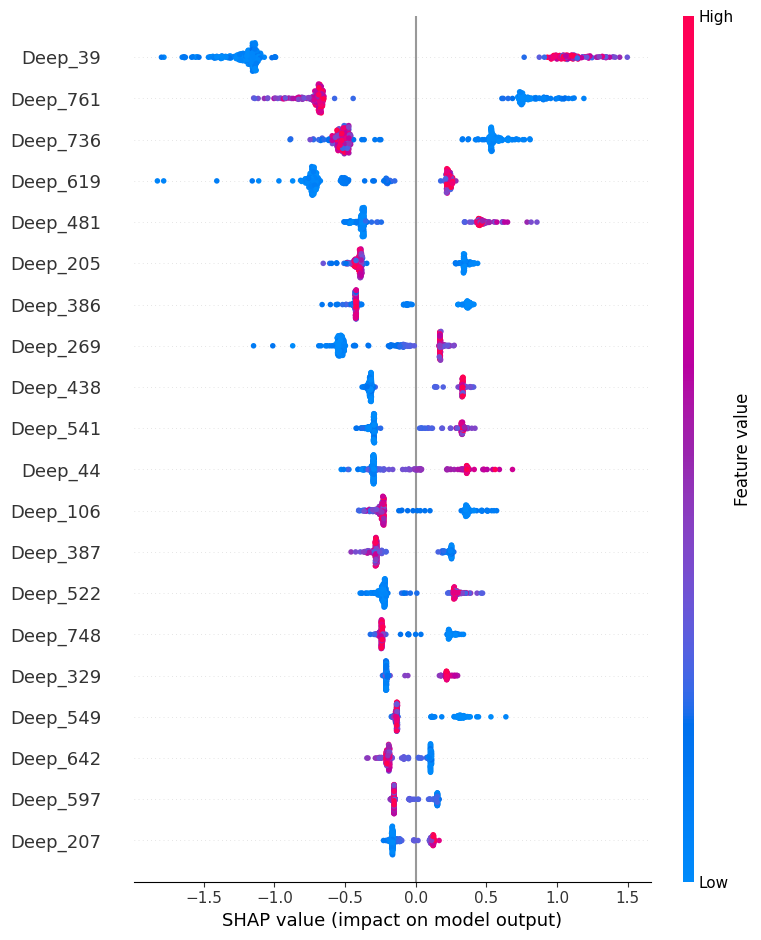

In [48]:
plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=fusion_feature_names,
    max_display=20,
    show=False
)

plt.tight_layout()

plt.savefig(
    "ERSF_SHAP_Summary.tiff",
    dpi=600,
    bbox_inches="tight",
    format="tiff"
)

plt.show()

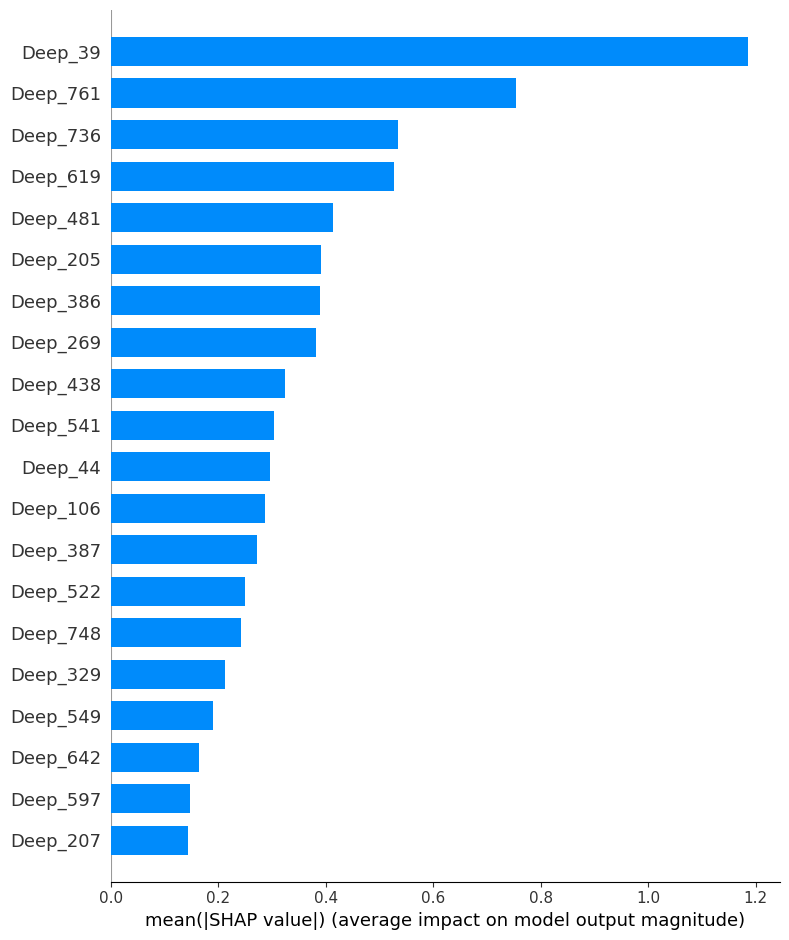

In [49]:
plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=fusion_feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.tight_layout()

plt.savefig(
    "ERSF_SHAP_Bar.tiff",
    dpi=600,
    bbox_inches="tight",
    format="tiff"
)

plt.show()

In [50]:
importance = np.abs(
    shap_values
).mean(axis=0)

top_idx = np.argsort(
    importance
)[::-1][:20]

for i in top_idx:

    print(
        fusion_feature_names[i],
        "->",
        importance[i]
    )

Deep_39 -> 1.1857479
Deep_761 -> 0.75439507
Deep_736 -> 0.53361875
Deep_619 -> 0.52582026
Deep_481 -> 0.41361886
Deep_205 -> 0.39143246
Deep_386 -> 0.38866538
Deep_269 -> 0.38075185
Deep_438 -> 0.32347885
Deep_541 -> 0.30369177
Deep_44 -> 0.29564714
Deep_106 -> 0.286528
Deep_387 -> 0.27184027
Deep_522 -> 0.24920301
Deep_748 -> 0.24127729
Deep_329 -> 0.21265562
Deep_549 -> 0.19002914
Deep_642 -> 0.1631761
Deep_597 -> 0.14732224
Deep_207 -> 0.14269929


In [51]:
rad_importance = np.sum(
    importance[:23]
)

deep_importance = np.sum(
    importance[23:]
)

print(
    "Radiomics Contribution:",
    rad_importance
)

print(
    "Deep Contribution:",
    deep_importance
)

print(
    "Radiomics %:",
    100*rad_importance/
    (rad_importance+deep_importance)
)

print(
    "Deep %:",
    100*deep_importance/
    (rad_importance+deep_importance)
)

Radiomics Contribution: 0.0077775633
Deep Contribution: 9.985864
Radiomics %: 0.07782512
Deep %: 99.92218


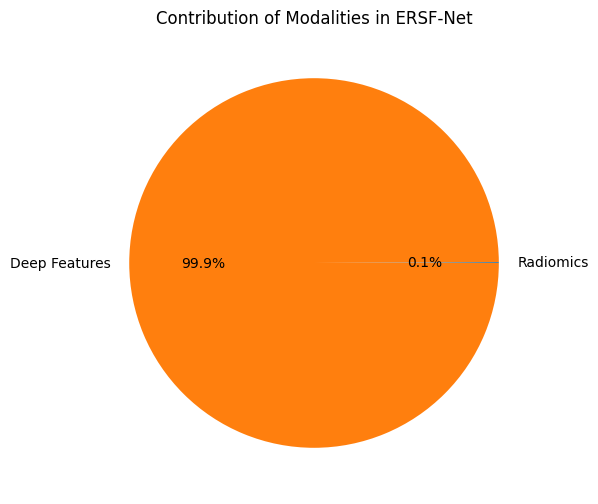

In [52]:
sizes = [
    rad_importance,
    deep_importance
]

labels = [
    "Radiomics",
    "Deep Features"
]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title(
    "Contribution of Modalities in ERSF-Net"
)

plt.savefig(
    "ERSF_Modality_Contribution.tiff",
    dpi=600,
    bbox_inches="tight",
    format="tiff"
)

plt.show()

In [53]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=64,
    random_state=42
)

X_train_deep_pca = pca.fit_transform(
    X_train_deep
)

X_val_deep_pca = pca.transform(
    X_val_deep
)

X_test_deep_pca = pca.transform(
    X_test_deep
)

print(X_train_deep_pca.shape)

(8234, 64)


In [54]:
X_train_deep_att = adaptive_attention(
    X_train_deep_pca
)

X_val_deep_att = adaptive_attention(
    X_val_deep_pca
)

X_test_deep_att = adaptive_attention(
    X_test_deep_pca
)

In [55]:
X_train_fusion = np.concatenate(
    [X_train_rad_att,
     X_train_deep_att],
    axis=1
)

X_val_fusion = np.concatenate(
    [X_val_rad_att,
     X_val_deep_att],
    axis=1
)

X_test_fusion = np.concatenate(
    [X_test_rad_att,
     X_test_deep_att],
    axis=1
)

print(X_train_fusion.shape)

(8234, 87)


In [59]:
from sklearn.decomposition import PCA

# =====================================================
# Reduce 768-D Swin embeddings to 64-D
# =====================================================

pca = PCA(
    n_components=64,
    random_state=42
)

X_train_deep_pca = pca.fit_transform(X_train_deep)
X_val_deep_pca   = pca.transform(X_val_deep)
X_test_deep_pca  = pca.transform(X_test_deep)

print("Train:", X_train_deep_pca.shape)
print("Val  :", X_val_deep_pca.shape)
print("Test :", X_test_deep_pca.shape)

# Variance retained
print("\nExplained Variance Ratio:",
      np.sum(pca.explained_variance_ratio_))

Train: (8234, 64)
Val  : (1696, 64)
Test : (1766, 64)

Explained Variance Ratio: 0.9247712


In [60]:
import numpy as np

def adaptive_attention(X):

    attention_weights = 1 / (1 + np.exp(-X))

    X_attention = X * attention_weights

    return X_attention

In [61]:
# =====================================================
# Radiomics Attention
# =====================================================

X_train_rad_att = adaptive_attention(X_train_rad)
X_val_rad_att   = adaptive_attention(X_val_rad)
X_test_rad_att  = adaptive_attention(X_test_rad)

# =====================================================
# Deep Attention
# =====================================================

X_train_deep_att = adaptive_attention(X_train_deep_pca)
X_val_deep_att   = adaptive_attention(X_val_deep_pca)
X_test_deep_att  = adaptive_attention(X_test_deep_pca)

print(X_train_rad_att.shape)
print(X_train_deep_att.shape)

(8234, 23)
(8234, 64)


In [62]:
# =====================================================
# Feature Fusion
# =====================================================

X_train_fusion = np.concatenate(
    [X_train_rad_att,
     X_train_deep_att],
    axis=1
)

X_val_fusion = np.concatenate(
    [X_val_rad_att,
     X_val_deep_att],
    axis=1
)

X_test_fusion = np.concatenate(
    [X_test_rad_att,
     X_test_deep_att],
    axis=1
)

print("Train Fusion:", X_train_fusion.shape)
print("Val Fusion  :", X_val_fusion.shape)
print("Test Fusion :", X_test_fusion.shape)

Train Fusion: (8234, 87)
Val Fusion  : (1696, 87)
Test Fusion : (1766, 87)


In [63]:
from xgboost import XGBClassifier

ratio = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

ersf_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

ersf_model.fit(
    X_train_fusion,
    y_train
)

print("Improved ERSF-Net Trained Successfully")

Improved ERSF-Net Trained Successfully


In [64]:
from sklearn.metrics import *

preds = ersf_model.predict(X_test_fusion)

probs = ersf_model.predict_proba(
    X_test_fusion
)[:,1]

acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds)
rec = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)
auc = roc_auc_score(y_test, probs)

print("\nImproved ERSF-Net Results\n")

print("Accuracy :", round(acc,4))
print("Precision:", round(prec,4))
print("Recall   :", round(rec,4))
print("F1 Score :", round(f1,4))
print("AUROC    :", round(auc,4))


Improved ERSF-Net Results

Accuracy : 0.9122
Precision: 0.8285
Recall   : 0.8638
F1 Score : 0.8458
AUROC    : 0.9407


In [65]:
import shap

# =====================================================
# Feature Names
# =====================================================

deep_names = [f"Deep_{i}" for i in range(64)]

fusion_feature_names = (
    list(RAD_FEATURES) +
    deep_names
)

# =====================================================
# Sample Data
# =====================================================

sample_size = 300

idx = np.random.choice(
    len(X_test_fusion),
    sample_size,
    replace=False
)

X_sample = X_test_fusion[idx]

# =====================================================
# SHAP
# =====================================================

explainer = shap.TreeExplainer(ersf_model)

shap_values = explainer.shap_values(X_sample)

importance = np.abs(
    shap_values
).mean(axis=0)

# =====================================================
# Contribution Analysis
# =====================================================

rad_importance = np.sum(
    importance[:23]
)

deep_importance = np.sum(
    importance[23:]
)

print("\nContribution Analysis\n")

print("Radiomics Contribution:",
      rad_importance)

print("Deep Contribution:",
      deep_importance)

print("\nRadiomics %:",
      100*rad_importance/
      (rad_importance+deep_importance))

print("Deep %:",
      100*deep_importance/
      (rad_importance+deep_importance))


Contribution Analysis

Radiomics Contribution: 0.39090118
Deep Contribution: 10.324816

Radiomics %: 3.6479237
Deep %: 96.35207


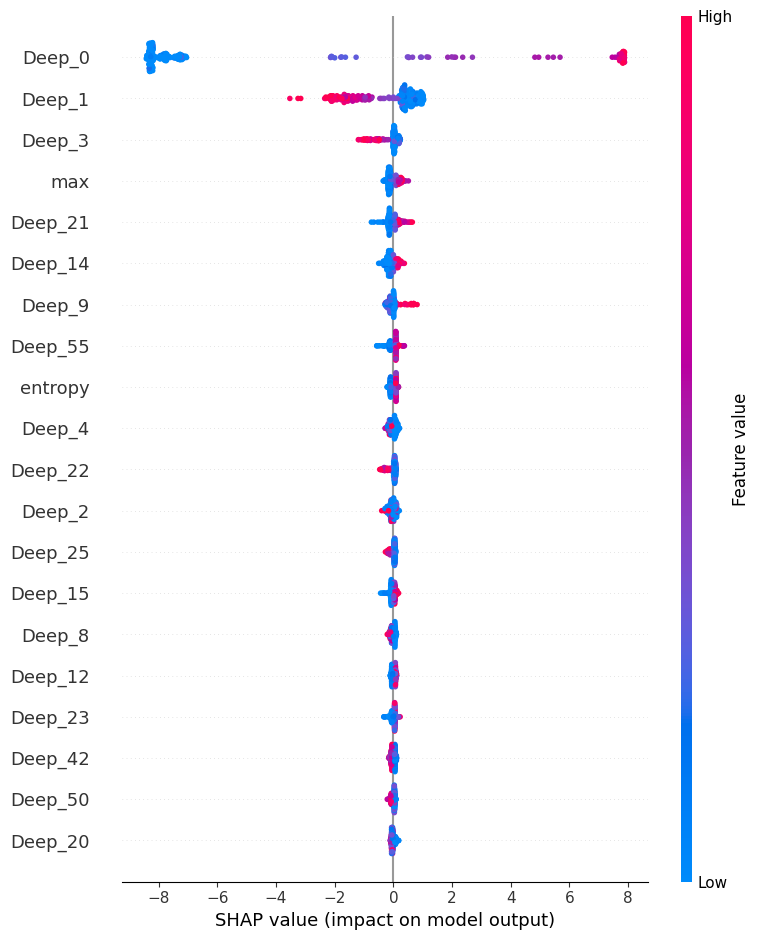

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=fusion_feature_names,
    max_display=20,
    show=False
)

plt.tight_layout()

plt.savefig(
    "Improved_ERSF_SHAP_Summary.tiff",
    dpi=600,
    bbox_inches="tight",
    format='tiff'
)

plt.show()

In [67]:
import pandas as pd

results = pd.DataFrame({

    "Model":[
        "Whole Slice Swin",
        "Radiomics + XGBoost",
        "ROI-Swin",
        "ERSF-Net"
    ],

    "Accuracy":[
        0.7916,
        0.8873,
        0.9162,
        0.9139
    ],

    "Precision":[
        0.6762,
        0.7602,
        0.8510,
        0.8232
    ],

    "Recall":[
        0.4797,
        0.8699,
        0.8476,
        0.8801
    ],

    "F1_Score":[
        0.5612,
        0.8114,
        0.8493,
        0.8507
    ],

    "AUROC":[
        0.8085,
        0.9583,
        0.9724,
        0.9729
    ]
})

results

,Model,Accuracy,Precision,Recall,F1_Score,AUROC
0,Whole Slice Swin,0.7916,0.6762,0.4797,0.5612,0.8085
1,Radiomics + XGBoost,0.8873,0.7602,0.8699,0.8114,0.9583
2,ROI-Swin,0.9162,0.8510,0.8476,0.8493,0.9724
3,ERSF-Net,0.9139,0.8232,0.8801,0.8507,0.9729


In [68]:
results.to_csv(
    "/kaggle/working/Table_Results.csv",
    index=False
)

results.to_excel(
    "/kaggle/working/Table_Results.xlsx",
    index=False
)

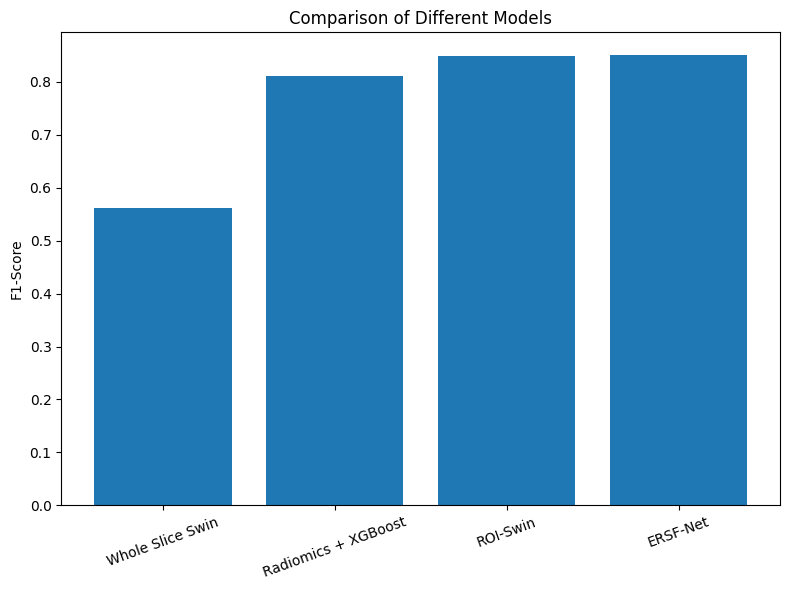

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

x = range(len(results))

plt.bar(
    x,
    results["F1_Score"]
)

plt.xticks(
    x,
    results["Model"],
    rotation=20
)

plt.ylabel("F1-Score")

plt.title(
    "Comparison of Different Models"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/Figure_Model_Comparison.tiff",
    dpi=600,
    format='tiff',
    bbox_inches='tight'
)

plt.show()

In [70]:
plt.savefig(
    "/kaggle/working/Figure_ERSF_CM.tiff",
    dpi=600,
    bbox_inches='tight',
    format='tiff'
)

<Figure size 640x480 with 0 Axes>

In [71]:
plt.savefig(
    "/kaggle/working/Figure_WholeSwin_CM.tiff",
    dpi=600,
    bbox_inches='tight',
    format='tiff'
)

<Figure size 640x480 with 0 Axes>

In [73]:
plt.savefig(
    "/kaggle/working/Figure_Radiomics_CM.tiff",
    dpi=600,
    bbox_inches='tight',
    format='tiff'
)

<Figure size 640x480 with 0 Axes>

In [74]:
plt.savefig(
    "/kaggle/working/Figure_ROISwin_CM.tiff",
    dpi=600,
    bbox_inches='tight',
    format='tiff'
)

<Figure size 640x480 with 0 Axes>

In [75]:
plt.savefig(
    "/kaggle/working/Figure_ERSF_CM.tiff",
    dpi=600,
    bbox_inches='tight',
    format='tiff'
)

<Figure size 640x480 with 0 Axes>

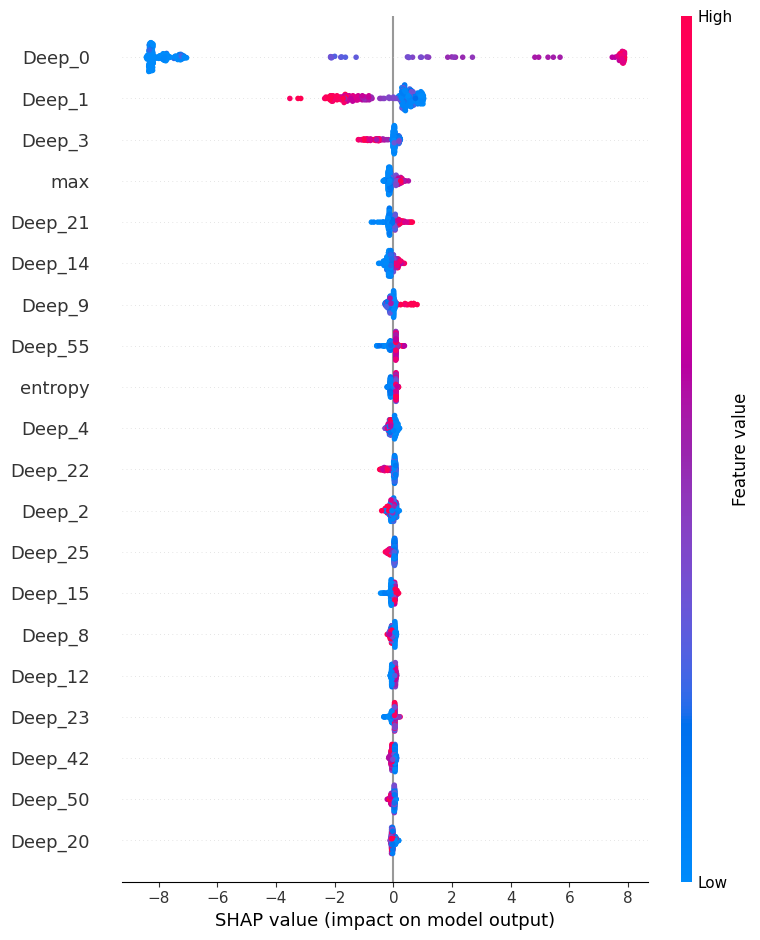

In [76]:
import shap
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=fusion_feature_names,
    max_display=20,
    show=False
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/ERSF_SHAP_Summary.tiff",
    dpi=600,
    bbox_inches='tight',
    format='tiff'
)

plt.show()

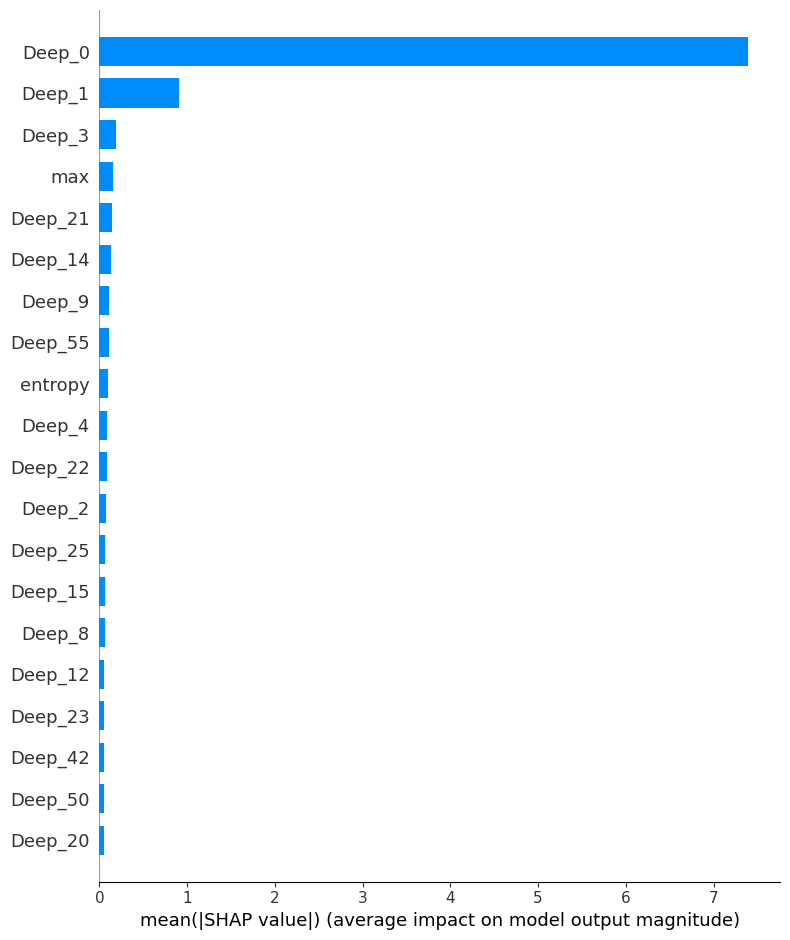

In [77]:
plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=fusion_feature_names,
    plot_type='bar',
    max_display=20,
    show=False
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/ERSF_SHAP_Bar.tiff",
    dpi=600,
    bbox_inches='tight',
    format='tiff'
)

plt.show()

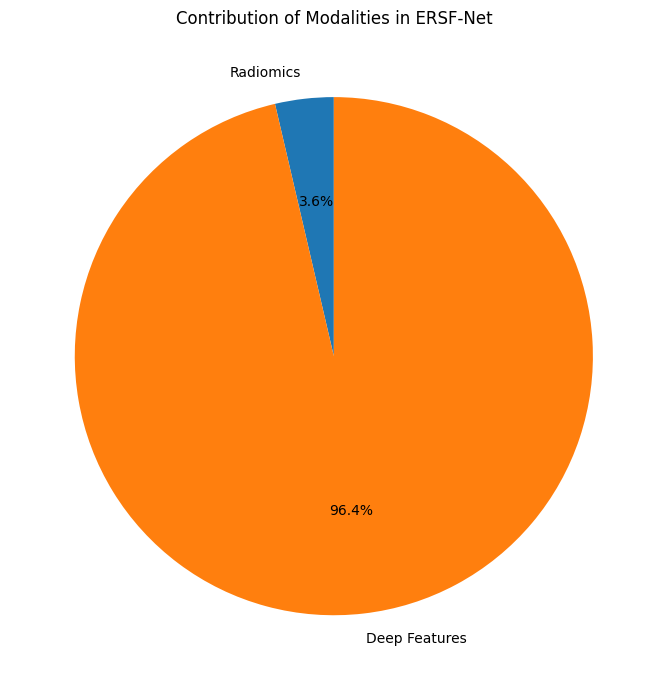

In [78]:
import matplotlib.pyplot as plt

sizes = [rad_importance, deep_importance]

labels = ['Radiomics', 'Deep Features']

plt.figure(figsize=(7,7))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    'Contribution of Modalities in ERSF-Net'
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/ERSF_Modality_Contribution.tiff",
    dpi=600,
    bbox_inches='tight',
    format='tiff'
)

plt.show()

In [79]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 92.5 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 109.8 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda

In [80]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [81]:
import timm

model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=False,
    num_classes=2
)

model.load_state_dict(
    torch.load("roi_swin_best.pth")
)

model = model.to(device)
model.eval()

print("ROI-Swin Loaded")

ROI-Swin Loaded


In [82]:
target_layers = [model.layers[-1].blocks[-1].norm1]

In [83]:
def reshape_transform(tensor):

    result = tensor.reshape(
        tensor.size(0),
        7,
        7,
        tensor.size(2)
    )

    result = result.permute(
        0, 3, 1, 2
    )

    return result

In [87]:
cam = GradCAM(
    model=model,
    target_layers = [model.norm],
    reshape_transform=reshape_transform
)

In [88]:
import random
import os

sample_folder = TEST_DIR + "/tumor"

samples = random.sample(
    os.listdir(sample_folder),
    5
)

print(samples)

['pancreas_127_37.png', 'pancreas_235_33.png', 'pancreas_377_18.png', 'pancreas_191_30.png', 'pancreas_125_19.png']


In [92]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import timm

from PIL import Image
from torchvision import transforms

from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [93]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=False,
    num_classes=2
)

model.load_state_dict(
    torch.load("roi_swin_best.pth")
)

model = model.to(device)
model.eval()

print("Model Loaded")

Model Loaded


In [94]:
def reshape_transform(tensor):

    if len(tensor.shape) == 3:

        h = int(np.sqrt(tensor.shape[1]))
        w = h

        tensor = tensor.reshape(
            tensor.size(0),
            h,
            w,
            tensor.size(2)
        )

    result = tensor.permute(0, 3, 1, 2)

    return result

In [95]:
target_layers = [model.norm]

In [96]:
cam = EigenCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

In [97]:
sample_folder = TEST_DIR + "/tumor"

samples = random.sample(
    os.listdir(sample_folder),
    5
)

print(samples)

['pancreas_379_40.png', 'pancreas_210_25.png', 'pancreas_346_11.png', 'pancreas_157_16.png', 'pancreas_083_38.png']


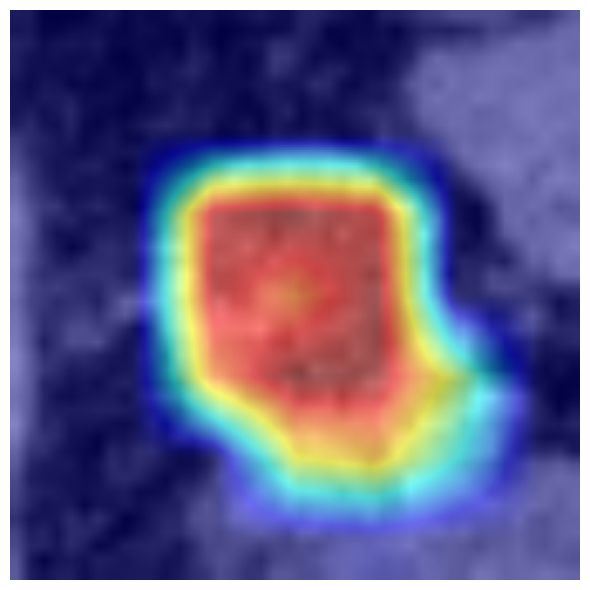

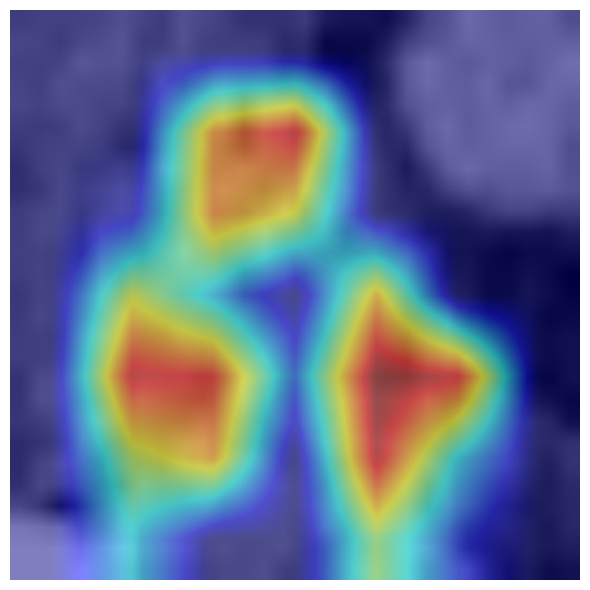

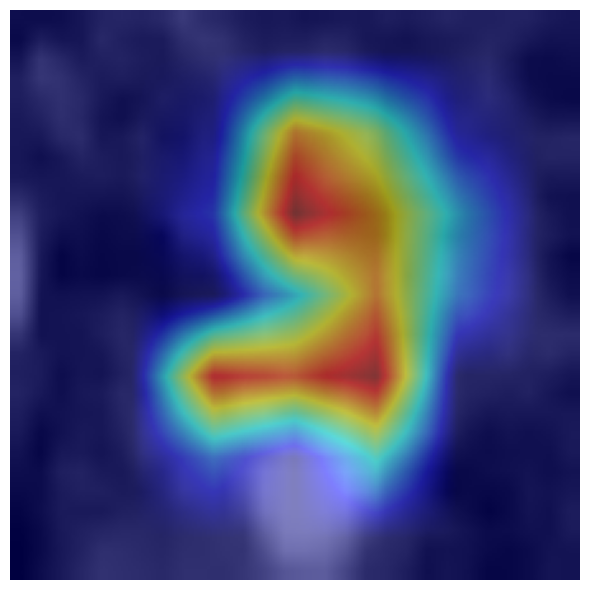

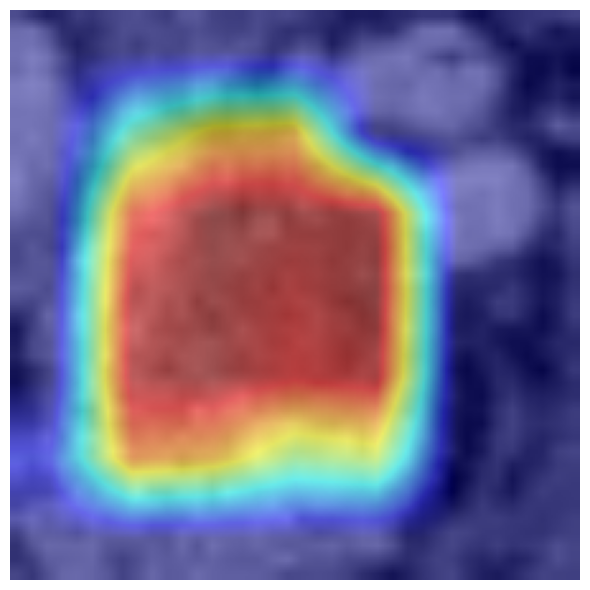

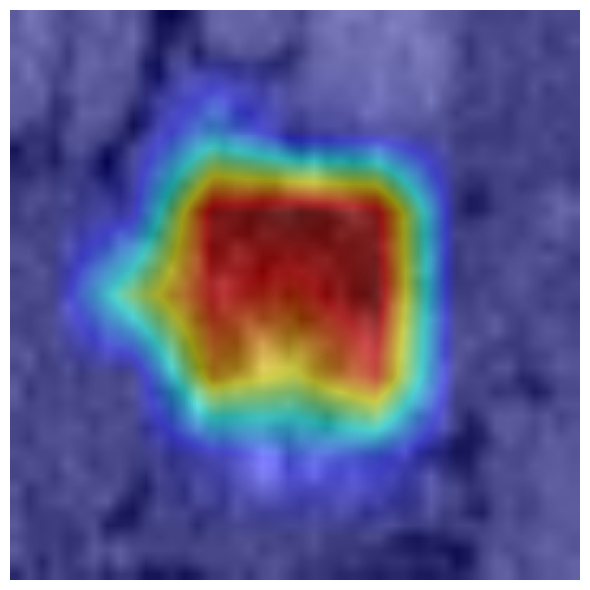

In [98]:
transform = transforms.Compose([

    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

for idx, fname in enumerate(samples):

    img_path = os.path.join(
        sample_folder,
        fname
    )

    pil_img = Image.open(img_path)

    rgb_img = np.array(
        pil_img.convert('RGB')
    ).astype(np.float32)/255.0

    input_tensor = transform(
        pil_img
    ).unsqueeze(0).to(device)

    grayscale_cam = cam(
        input_tensor=input_tensor
    )[0]

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    plt.figure(figsize=(6,6))

    plt.imshow(visualization)

    plt.axis("off")

    plt.tight_layout()

    plt.savefig(
        f"/kaggle/working/EigenCAM_{idx+1}.tiff",
        dpi=600,
        bbox_inches='tight',
        format='tiff'
    )

    plt.show()

In [99]:
import os
import zipfile

zip_filename = "/kaggle/working/ERSF_COMPLETE_PROJECT.zip"

with zipfile.ZipFile(
        zip_filename,
        'w',
        zipfile.ZIP_DEFLATED) as zipf:

    for root, dirs, files in os.walk("/kaggle/working"):

        for file in files:

            if file.endswith((
                    '.tiff',
                    '.png',
                    '.jpg',
                    '.csv',
                    '.xlsx',
                    '.pth',
                    '.pkl',
                    '.npy',
                    '.txt',
                    '.json'
            )):

                filepath = os.path.join(root, file)

                zipf.write(
                    filepath,
                    arcname=os.path.relpath(
                        filepath,
                        "/kaggle/working"
                    )
                )

print("="*60)
print("MASTER ZIP CREATED SUCCESSFULLY")
print(zip_filename)
print("="*60)

size = os.path.getsize(zip_filename)/(1024**3)

print(f"ZIP Size : {size:.2f} GB")

MASTER ZIP CREATED SUCCESSFULLY
/kaggle/working/ERSF_COMPLETE_PROJECT.zip
ZIP Size : 0.13 GB


In [100]:
import zipfile

with zipfile.ZipFile(
        "/kaggle/working/ERSF_COMPLETE_PROJECT.zip",
        'r') as z:

    print("Total Files :", len(z.namelist()))

    for file in z.namelist():
        print(file)

Total Files : 20
val_swin_embeddings.npy
Table_Results.xlsx
Figure_ERSF_CM.tiff
Figure_Radiomics_CM.tiff
ERSF_Modality_Contribution.tiff
Figure_ROISwin_CM.tiff
Figure_Model_Comparison.tiff
ERSF_SHAP_Bar.tiff
Improved_ERSF_SHAP_Summary.tiff
Figure_WholeSwin_CM.tiff
EigenCAM_1.tiff
roi_swin_best.pth
EigenCAM_3.tiff
Table_Results.csv
train_swin_embeddings.npy
EigenCAM_5.tiff
EigenCAM_2.tiff
test_swin_embeddings.npy
ERSF_SHAP_Summary.tiff
EigenCAM_4.tiff


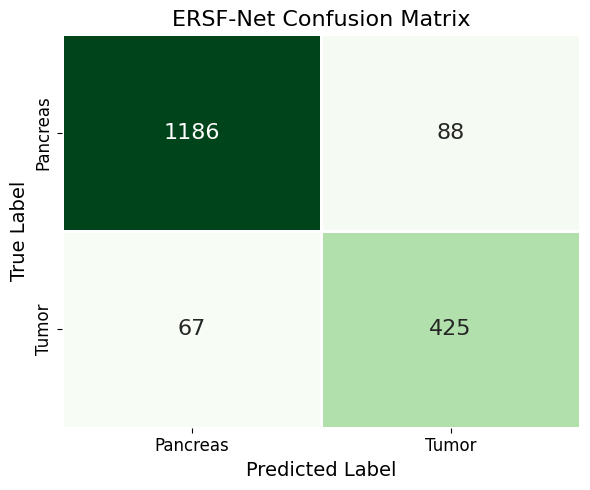

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, preds)

# Create figure
fig, ax = plt.subplots(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False,
    annot_kws={"size":16},
    linewidths=1,
    linecolor='white',
    ax=ax
)

ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
ax.set_title('ERSF-Net Confusion Matrix', fontsize=16)

ax.set_xticklabels(['Pancreas','Tumor'], fontsize=12)
ax.set_yticklabels(['Pancreas','Tumor'], fontsize=12)

plt.tight_layout()

# IMPORTANT: Save BEFORE plt.show()
fig.savefig(
    "/kaggle/working/Figure_ERSF_CM.tiff",
    dpi=600,
    bbox_inches='tight',
    format='tiff'
)

plt.show()

plt.close(fig)

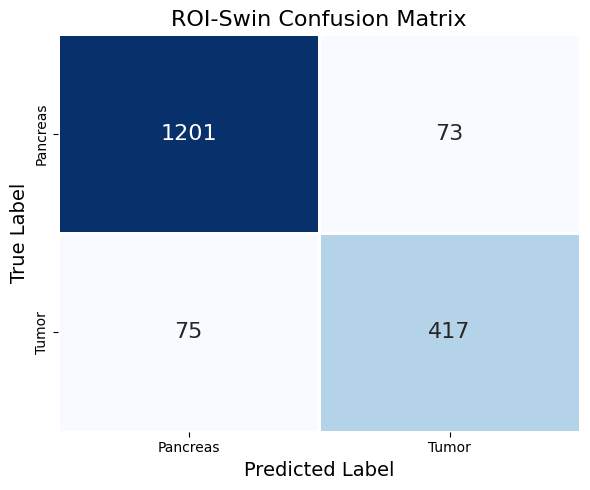

In [102]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    annot_kws={"size":16},
    linewidths=1,
    linecolor='white',
    ax=ax
)

ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
ax.set_title('ROI-Swin Confusion Matrix', fontsize=16)

ax.set_xticklabels(['Pancreas','Tumor'])
ax.set_yticklabels(['Pancreas','Tumor'])

plt.tight_layout()

fig.savefig(
    "/kaggle/working/Figure_ROISwin_CM.tiff",
    dpi=600,
    bbox_inches='tight',
    format='tiff'
)

plt.show()

plt.close(fig)

In [103]:
fig.savefig(
    "/kaggle/working/Figure_ERSF_CM.png",
    dpi=600,
    bbox_inches='tight'
)

fig.savefig(
    "/kaggle/working/Figure_ERSF_CM.tiff",
    dpi=600,
    bbox_inches='tight',
    format='tiff'
)

In [106]:
test_preds = xgb_model.predict(X_test_rad)

NameError: name 'xgb_model' is not defined

In [107]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'os', '_i2', '_i3', 'root', 'dirs', 'files', 'file', '_i4', 'dataset_path', '_i5', 'plt', 'cv2', 'img_dir', 'images', 'i', 'img', '_i6', 'np', 'torch', 'nn', 'DataLoader', 'datasets', 'transforms', 'timm', 'accuracy_score', 'precision_score', 'recall_score', 'f1_score', 'roc_auc_score', 'confusion_matrix', 'sns', 'device', '_i7', 'TRAIN_DIR', 'VAL_DIR', 'TEST_DIR', '_i8', '_i9', 'train_transform', 'test_transform', '_i10', 'train_dataset', 'val_dataset', 'test_dataset', '_i11', 'BATCH_SIZE', 'train_loader', 'val_loader', 'test_loader', '_i12', 'Counter', 'targets', 'counter', 'weights', '_i13', 'model', 'criterion', 'optimizer', '_i14', 'EPOCHS', 'PATIENCE', '_i15', '_i16', 'best_f1', 'patience', '_i17', '_i18', 'copy', 'patience_counter', 'best_model', 'epoch', 'running_l

In [108]:
from xgboost import XGBClassifier

ratio = (y_train == 0).sum() / (y_train == 1).sum()

radiomics_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)

radiomics_model.fit(
    X_train_rad,
    y_train
)

print("Radiomics Model Trained")

Radiomics Model Trained


In [109]:
test_preds = radiomics_model.predict(X_test_rad)

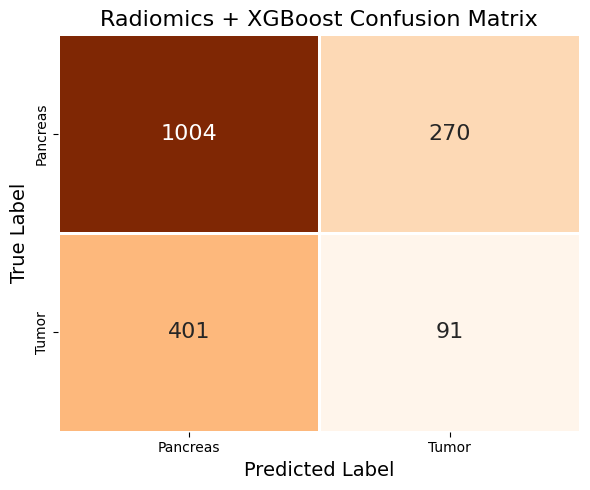

In [110]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, test_preds)

fig, ax = plt.subplots(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    cbar=False,
    annot_kws={"size":16},
    linewidths=1,
    linecolor='white',
    ax=ax
)

ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
ax.set_title('Radiomics + XGBoost Confusion Matrix', fontsize=16)

ax.set_xticklabels(['Pancreas','Tumor'])
ax.set_yticklabels(['Pancreas','Tumor'])

plt.tight_layout()

fig.savefig(
    "/kaggle/working/Figure_Radiomics_CM.tiff",
    dpi=600,
    bbox_inches='tight',
    format='tiff'
)

plt.show()

plt.close(fig)

In [111]:
import os

print("Image files in /kaggle/working:\n")

for file in os.listdir("/kaggle/working"):
    if file.endswith(('.tiff', '.png', '.jpg', '.jpeg')):
        print(file)

Image files in /kaggle/working:

Figure_ERSF_CM.tiff
Figure_Radiomics_CM.tiff
ERSF_Modality_Contribution.tiff
Figure_ROISwin_CM.tiff
Figure_Model_Comparison.tiff
ERSF_SHAP_Bar.tiff
Improved_ERSF_SHAP_Summary.tiff
Figure_WholeSwin_CM.tiff
Figure_ERSF_CM.png
EigenCAM_1.tiff
EigenCAM_3.tiff
EigenCAM_5.tiff
EigenCAM_2.tiff
ERSF_SHAP_Summary.tiff
EigenCAM_4.tiff


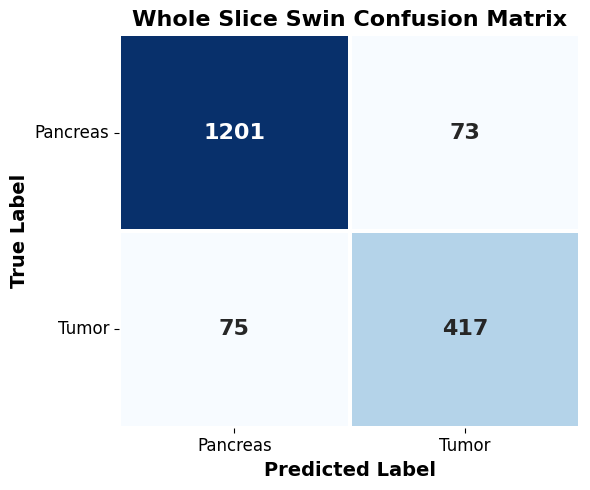

In [112]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Create figure
fig, ax = plt.subplots(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    annot_kws={"size":16, "weight":"bold"},
    linewidths=1.5,
    linecolor='white',
    ax=ax
)

ax.set_xlabel(
    'Predicted Label',
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel(
    'True Label',
    fontsize=14,
    fontweight='bold'
)

ax.set_title(
    'Whole Slice Swin Confusion Matrix',
    fontsize=16,
    fontweight='bold'
)

ax.set_xticklabels(
    ['Pancreas', 'Tumor'],
    fontsize=12
)

ax.set_yticklabels(
    ['Pancreas', 'Tumor'],
    fontsize=12,
    rotation=0
)

plt.tight_layout()

# Save BEFORE show()
fig.savefig(
    "/kaggle/working/Figure_WholeSwin_CM.tiff",
    dpi=600,
    bbox_inches='tight',
    format='tiff'
)

# Optional PNG backup
fig.savefig(
    "/kaggle/working/Figure_WholeSwin_CM.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

plt.close(fig)